In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [56]:
# Read excel file

df = pd.read_csv('stroke.csv')
df.drop(columns=['id'], inplace=True)
# Fillna with median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

/var/folders/ll/2dw3c8w16bq4l6d2zkwh1ct40000gn/T/ipykernel_53836/2254919290.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [57]:
numerical_variables = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_variables = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [58]:
df = pd.get_dummies(df, columns=categorical_variables, drop_first=True, dtype=int)

<Axes: >

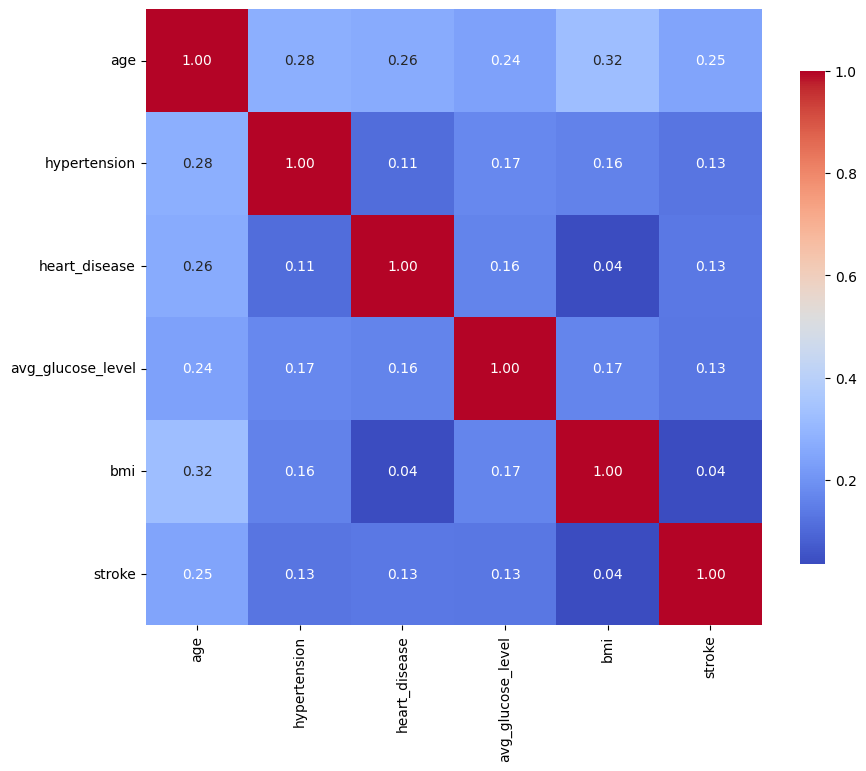

In [59]:
# Create a correlation matrix
correlation_matrix = df[numerical_variables].corr()
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={"shrink": .8})

In [60]:
df = sm.add_constant(df)

# Train-test-split
from sklearn.model_selection import train_test_split
X = df.drop(columns=['stroke'])
y = df['stroke']

# Combat imbalanced classes with smote
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Fit logistic glm

In [61]:
print(y_train.dtype)
print(X_train.dtypes)

int64
const                             float64
age                               float64
hypertension                        int64
heart_disease                       int64
avg_glucose_level                 float64
bmi                               float64
gender_Male                         int64
gender_Other                        int64
ever_married_Yes                    int64
work_type_Never_worked              int64
work_type_Private                   int64
work_type_Self-employed             int64
work_type_children                  int64
Residence_type_Urban                int64
smoking_status_formerly smoked      int64
smoking_status_never smoked         int64
smoking_status_smokes               int64
dtype: object


In [62]:
binomial = sm.GLM(y_train, X_train, family=sm.families.Binomial())
result = binomial.fit()
# Print the summary of the model
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 stroke   No. Observations:                 7777
Model:                            GLM   Df Residuals:                     7760
Model Family:                Binomial   Df Model:                           16
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2377.2
Date:                Sat, 05 Jul 2025   Deviance:                       4754.4
Time:                        20:41:53   Pearson chi2:                 7.39e+03
No. Iterations:                    22   Pseudo R-squ. (CS):             0.5393
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

              precision    recall  f1-score   support

           0       0.87      0.86      0.86       975
           1       0.86      0.87      0.86       970

    accuracy                           0.86      1945
   macro avg       0.86      0.86      0.86      1945
weighted avg       0.86      0.86      0.86      1945



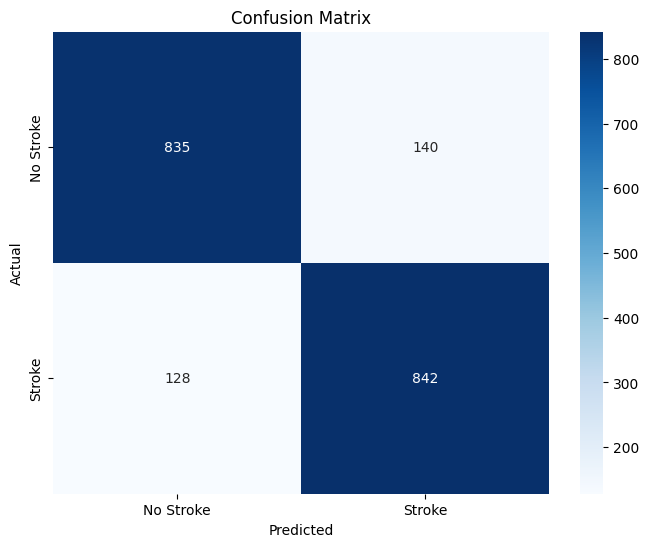

In [64]:
# Benchmark against test data
y_pred = result.predict(X_test)
# Convert probabilities to binary predictions
y_pred_binary = (y_pred > 0.5).astype(int)
from sklearn.metrics import classification_report, confusion_matrix
# Print classification report
print(classification_report(y_test, y_pred_binary))
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

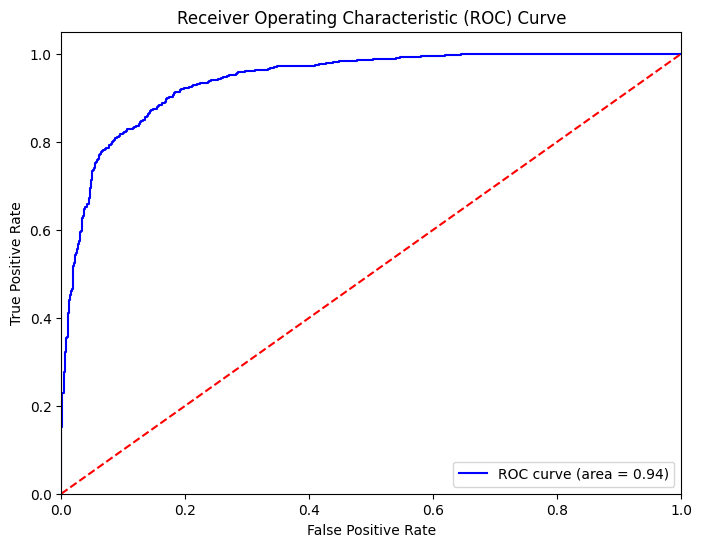

In [65]:
# Plot ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

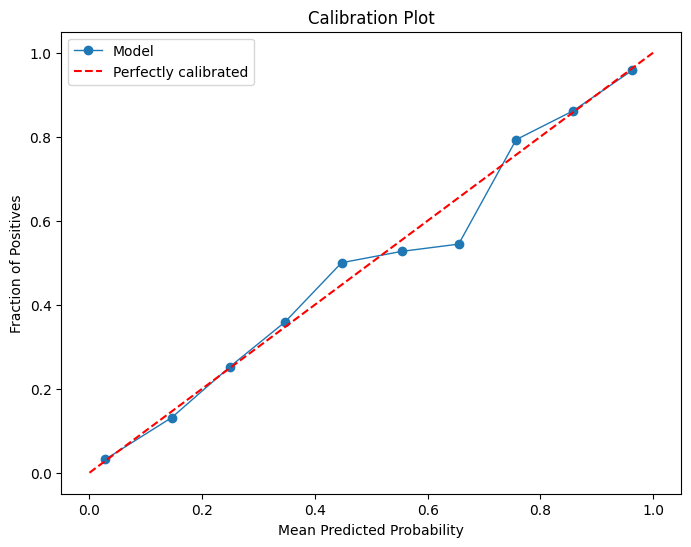

In [66]:
# Check calibration
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_pred, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend()
plt.show()

# Fit GAM

In [ ]:
X_train

In [90]:
from statsmodels.gam.api import GLMGam, BSplines
spline_cols = ['age', 'bmi', 'avg_glucose_level']

# Degrees of freedom for splines (number of knots - 1)
df = [3, 3, 3]

# Degree of spline basis (usually 3 = cubic)
degree = [3, 3, 3]

# Create spline basis
bs = BSplines(X_train[spline_cols], df=[4, 4, 4], degree=[3, 3, 3])

binomial_gam = sm.GLMGam(y_train, X_train, family=sm.families.Binomial(), smoother=bs)
result_gam = binomial_gam.fit()
# Print the summary of the GAM model
print(result_gam.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 stroke   No. Observations:                 7777
Model:                         GLMGam   Df Residuals:                  7755.26
Model Family:                Binomial   Df Model:                        20.74
Link Function:                  Logit   Scale:                          1.0000
Method:                         PIRLS   Log-Likelihood:                -2301.8
Date:                Sat, 05 Jul 2025   Deviance:                       4603.7
Time:                        21:13:42   Pearson chi2:                 6.88e+03
No. Iterations:                    23   Pseudo R-squ. (CS):             0.5481
Covariance Type:            nonrobust                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [89]:
# Assuming X_train and X_test have the same columns
spline_cols = ['age', 'bmi', 'avg_glucose_level']
# Get the columns that are not part of the splines
other_cols = [col for col in X_train.columns if col not in spline_cols]

# Start with the columns that are not smoothed
X_test_transformed = X_test[other_cols].copy()
bs.transform(X_train[spline_cols])

# # Transform the spline columns using the bs object and get column names
# spline_test_df = pd.DataFrame(bs.transform(X_test[spline_cols]), 
#                               columns=bs.col_names)

# # Combine the non-spline and transformed spline columns
# # Note: It's crucial to reset index to ensure a clean concatenation
# X_test_full = pd.concat([X_test_transformed.reset_index(drop=True), 
#                          spline_test_df.reset_index(drop=True)], 
#                         axis=1)

InvalidIndexError: (slice(None, None, None), 0)

In [78]:
import numpy as np
import matplotlib.pyplot as plt

var = 'age'
age_grid = np.linspace(X_train[var].min(), X_train[var].max(), 7777)

X_pred = X_train.copy()
for col in X_pred.columns:
    if col != var:
        if np.issubdtype(X_pred[col].dtype, np.number):
            X_pred[col] = X_pred[col].mean()
        else:
            X_pred[col] = X_pred[col].mode()[0]
X_pred[var] = age_grid

predicted_probs = result.predict(X_pred)

plt.plot(age_grid, predicted_probs)
plt.xlabel(var)
plt.ylabel('Predicted probability')
plt.title(f'Smooth effect of {var}')
plt.show()

ValueError: shapes (7777,17) and (50,) not aligned: 17 (dim 1) != 50 (dim 0)